In [1]:
#########################################################
# Notebook 06 – Erweitertes hedonisches Regressionsmodell
# Projekt: Preisbewertung NL
#########################################################

import sys
import statsmodels.api as sm
import pandas as pd
import numpy as np


In [2]:
# csv-Dateien laden

df_model = pd.read_csv('../data_clean/df_model_prepared.csv')
X = pd.read_csv('../data_clean/X_features.csv')
y = pd.read_csv('../data_clean/y_target.csv')

df_model['log_price_total'] = np.log(df_model['price_total'])
df_model['log_price_egw'] = np.log(df_model['price_egw'])
df_model['log_price_mgw'] = np.log(df_model['price_mgw'])


In [3]:
# Konstantenvektor hinzufügen

X_ols = sm.add_constant(X)


In [4]:
# Alle bool-Spalten in int umwandeln

bool_cols = X_ols.select_dtypes(include=['bool']).columns
X_ols[bool_cols] = X_ols[bool_cols].astype(int)


In [5]:
# Regressionsergebnisse auf Basis von 'log_price_total', 'log_price_egw' und 'log_price_mgw'

features = [
  'income_mean',
  'woz_mean',
  'log_density',
  'migration_per_1000',
  'employment_rate',
  'labor_participation_net',
  'longitude',
  'latitude',
  'is_randstad',
  'province_Flevoland',
  'province_Fryslân',
  'province_Gelderland',
  'province_Groningen',
  'province_Limburg',
  'province_Noord-Brabant',
  'province_Noord-Holland',
  'province_Overijssel',
  'province_Utrecht',
  'province_Zeeland',
  'province_Zuid-Holland',
  'ratio_price_model',
  'ratio_stock',
  'woningvoorraad_total',
  'pipeline_total',
  'new_build_stock_tot',
  'households'
]

targets = ["log_price_total", "log_price_egw", "log_price_mgw"]

for target in targets:
    print(f"\n===== Modell für {target} =====")
    y = df_model[target]

    df_model[features] = df_model[features].astype(float)

    X_ols = sm.add_constant(df_model[features])
    model = sm.OLS(y, X_ols).fit()
    print(model.summary())



===== Modell für log_price_total =====
                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     881.8
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:54:38   Log-Likelihood:                 2456.3
No. Observations:                1690   AIC:                            -4861.
Df Residuals:                    1664   BIC:                            -4719.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

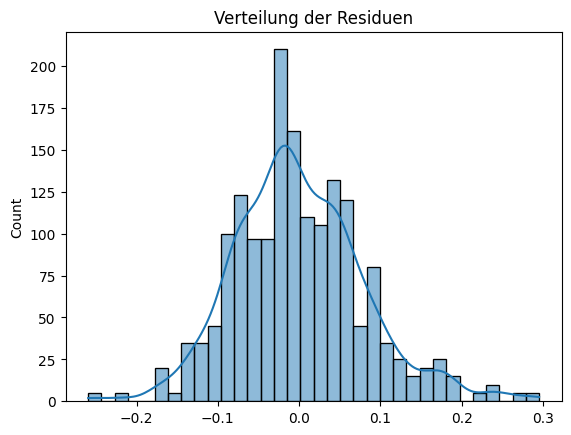

In [6]:
# Differenzen zwischen den tatsächlichen Werten und den vorhergesagten Werten prüfen

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(model.resid, kde=True)
plt.title("Verteilung der Residuen")
plt.show()